Data loaded successfully!
Total rows: 1792, Total columns: 13

Column names:
['OBJECTID', 'WUDS_ID', 'NAME', 'CNTY_CODE', 'CNTY_NAME', 'OWNERSHIP', 'GW_SOURCE', 'SW_SOURCE', 'INTCONNECT', 'LAST_DATE', 'PWS_ID', 'SHAPEAREA', 'SHAPELEN']

Number of water systems in Allegheny County: 36


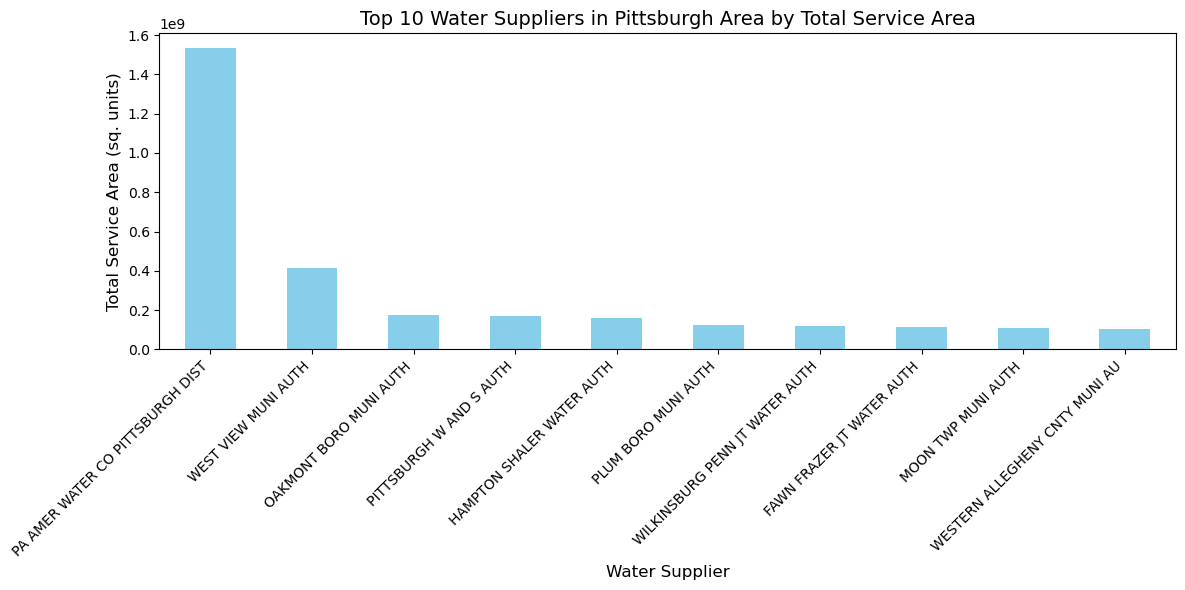


Top 5 Water Suppliers by Total Service Area:
NAME
PA AMER WATER CO PITTSBURGH DIST    1.532551e+09
WEST VIEW MUNI AUTH                 4.154344e+08
OAKMONT BORO MUNI AUTH              1.734880e+08
PITTSBURGH W AND S AUTH             1.717609e+08
HAMPTON SHALER WATER AUTH           1.599354e+08
Name: SHAPEAREA, dtype: float64

Sub-metric explanation: We use total water service area as a sub-metric for 'best neighborhood'.
Larger service area indicates broader water infrastructure coverage and better reliability for the community.


In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/public_water_systems_-_public_water_supplier_service_areas.csv")

# Data overview
print("Data loaded successfully!")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
df.head()

# Filter data for Allegheny County
pgh_water = df[df['CNTY_NAME'] == 'Allegheny']
print(f"\nNumber of water systems in Allegheny County: {len(pgh_water)}")

# Calculate total service area for each water supplier (NEW: area-based metric)
supplier_area = pgh_water.groupby('NAME')['SHAPEAREA'].sum().sort_values(ascending=False).head(10)

# Create visualization
plt.figure(figsize=(12, 6))
supplier_area.plot(kind='bar', color='skyblue')
plt.title('Top 10 Water Suppliers in Pittsburgh Area by Total Service Area', fontsize=14)
plt.xlabel('Water Supplier', fontsize=12)
plt.ylabel('Total Service Area (sq. units)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig("../images/water_supplier_top10_area.png", dpi=300, bbox_inches='tight')
plt.show()

# Sub-metric conclusion
print("\nTop 5 Water Suppliers by Total Service Area:")
print(supplier_area.head())
print("\nSub-metric explanation: We use total water service area as a sub-metric for 'best neighborhood'.")
print("Larger service area indicates broader water infrastructure coverage and better reliability for the community.")